This notebook gives an example of how one can use an **autoencoder** to **detect anomalies** in time series data.

In [2]:
# Libraries needed
import numpy as np
import pandas as pd
import keras
from keras import layers
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec

## The Data

The dataset we'll use is the Numenta Anomaly Benchmark (NAB) which provides artificial time series data containing labeled anomalous periods.

- **Training data file**: 'art_daily_small_noise.csv'
- **Testing data file**: 'art_daily_jumpsup.csv'

In [4]:
# Training data links.
master_url_root = "https://raw.githubusercontent.com/numenta/NAB/master/data/"
df_small_noise_url_suffix = "artificialNoAnomaly/art_daily_small_noise.csv"
df_small_noise_url = master_url_root + df_small_noise_url_suffix

# Training data reading.
df_small_noise = pd.read_csv(
    df_small_noise_url, parse_dates=True, index_col="timestamp"
)

# Testing data links.
df_daily_jumpsup_url_suffix = "artificialWithAnomaly/art_daily_jumpsup.csv"
df_daily_jumpsup_url = master_url_root + df_daily_jumpsup_url_suffix

# Testing data reading.
df_daily_jumpsup = pd.read_csv(
    df_daily_jumpsup_url, parse_dates=True, index_col="timestamp"
)

### Quick look at the data

In [5]:
df_small_noise.head()

,value
timestamp,
2014-04-01 00:00:00,18.324919
2014-04-01 00:05:00,21.970327
2014-04-01 00:10:00,18.624806
2014-04-01 00:15:00,21.953684
2014-04-01 00:20:00,21.909120


In [6]:
df_daily_jumpsup.head()

,value
timestamp,
2014-04-01 00:00:00,19.761252
2014-04-01 00:05:00,20.500833
2014-04-01 00:10:00,19.961641
2014-04-01 00:15:00,21.490266
2014-04-01 00:20:00,20.187739


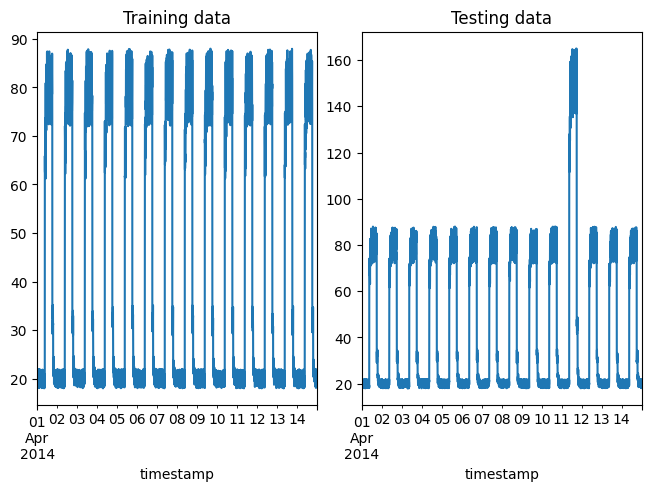

In [10]:
fig, ax = plt.subplots(nrows=1, ncols=2, constrained_layout=True)
df_small_noise.plot(legend=False, ax=ax[0], title='Training data')
df_daily_jumpsup.plot(legend=False, ax=ax[1], title='Testing data')
plt.show()

In [12]:
# Normalizing test data.
training_mean = df_small_noise.mean()
training_std = df_small_noise.std()
df_training_value = (df_small_noise - training_mean) / training_std

# Number of training data.
print(f'Number of training data points: {len(df_training_value)}')

Number of training data points: 4032


In [13]:
TIME_STEPS = 288


# Generated training sequences for use it in the model.
def create_sequences(values, time_steps=TIME_STEPS):
    output = []
    for i in range(len(values) - time_steps + 1):
        output.append(values[i : (i + time_steps)])
    return np.stack(output)


x_train = create_sequences(df_training_value.values)
print("Training input shape: ", x_train.shape) # 3745 data of shape (288,1)

Training input shape:  (3745, 288, 1)


## The Model
The model is a convolutional autoencoder.

In [16]:
# Input shape = (batch_size, 288, 1)
model = keras.Sequential(
    [
        # 1
        layers.Input(shape=(x_train.shape[1], x_train.shape[2])),
        # 2
        layers.Conv1D(filters=32, kernel_size=7, padding="same", strides=2, activation="relu"),
        # 3
        layers.Dropout(rate=0.2),
        # 4
        layers.Conv1D(filters=16, kernel_size=7, padding="same", strides=2, activation="relu"),
        # 5
        layers.Conv1DTranspose(filters=32, kernel_size=7, padding="same", strides=2, activation="relu"),
        # 6
        layers.Dropout(rate=0.2),
        # 7
        layers.Conv1DTranspose(filters=32, kernel_size=7, padding="same", strides=2, activation="relu"),
        # 8
        layers.Conv1DTranspose(filters=1, kernel_size=7, padding="same")
    ]
)

In [17]:
# Compile the model.
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

# Model summary.
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 144, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 144, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 72, 16)         │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_6              │ (None, 144, 32)        │         3,616 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 144, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_7              │ (None, 288, 32)        │         7,200 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_8              │ (None, 288, 1)         │           225 │
│ (Conv1DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,897 (58.19 KB)

 Trainable params: 14,897 (58.19 KB)

 Non-trainable params: 0 (0.00 B)

## Model training
Here, we are using `x_train` as both the **input** and the **target** since this is a reconstruction model.

In [18]:
## Model training
history = model.fit(
    x_train,
    x_train,
    epochs=50,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.6722 - val_loss: 0.0593
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0737 - val_loss: 0.0415
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0527 - val_loss: 0.0317
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0436 - val_loss: 0.0267
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0373 - val_loss: 0.0235
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0331 - val_loss: 0.0205
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0297 - val_loss: 0.0194
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0272 - val_loss: 0.0173
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0253 - val_loss: 0.0165
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0237 - val_loss: 0.0158
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0225 - val_loss: 0.0151
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0

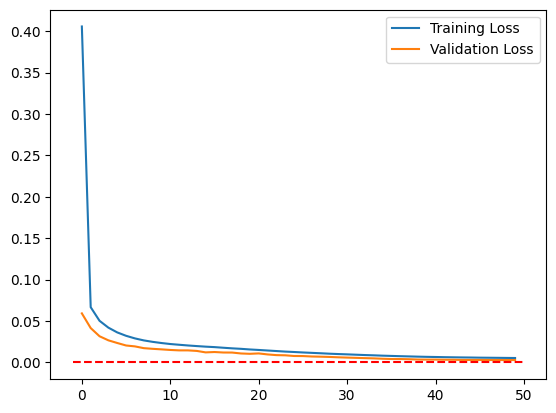

In [37]:
# Training and validation loss plots.
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.hlines(y=0, xmin=-1, xmax=50, linestyles='--', colors='red')
plt.legend()
plt.show()

## Anomalies detection
The question here is **how well the model is capable to reconstruct the input data**.
Our approach is:
1. Compute the MAE (Mean Absolute Error) loss on the training data.
2. Find the max of the MAE loss values. This is the worst the model performed trying to reconstruct a sample point. This value will be considered the *threshold* for anomalies detection.
3. Whenever the reconstruction loss of a sample is greater than the *threshold*, the sample will be considered as an **anomaly**.

In [21]:
# MAE loss computing.
x_train_pred = model.predict(x_train) # Make prediction from x_train.
train_mae_loss = np.mean(np.abs(x_train_pred - x_train) , axis=1) # Compute the mae loss.

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [22]:
x_train.shape

(3745, 288, 1)

In [24]:
train_mae_loss.shape

(3745, 1)

In [32]:
print('The minimum of loss:', round(train_mae_loss.min(), 3))

print('The maximum of loss:', round(train_mae_loss.max(), 3))

The minimum of loss: 0.034
The maximum of loss: 0.053


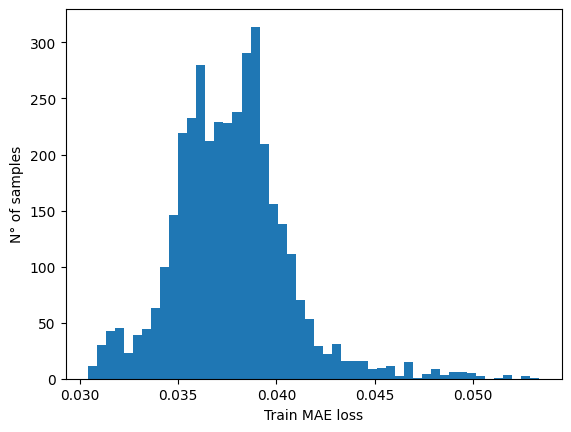

In [21]:
# MAE distribution.
plt.hist(train_mae_loss, bins=50)
plt.xlabel("Train MAE loss")
plt.ylabel("N° of samples")
plt.show()

In [52]:
# Get the threshold.
threshold = np.max(train_mae_loss)
print("Here is the value of anomalies threshold:", round(threshold, 4))

Here is the value of anomalies threshold: 0.0534


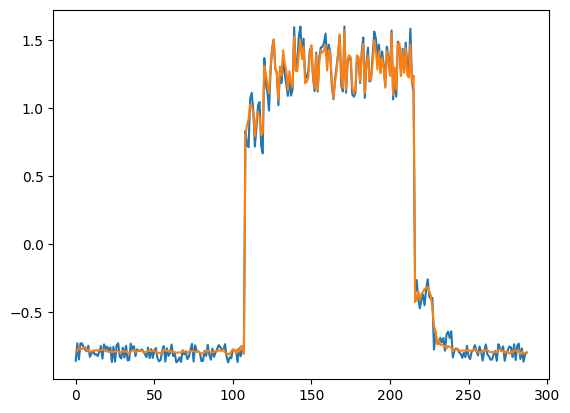

In [39]:
# How good is is the learning of the first sequence?
plt.plot(x_train[0], label="True seq")
plt.plot(x_train_pred[0], label="Recon seq")
plt.show()

## Preparing test data

In [42]:
# Scaling the test data.
df_test_value = (df_daily_jumpsup - training_mean) / training_std 

# Create sequences from the test data.
x_test = create_sequences(df_test_value.values)
print('Test data shape:', x_test.shape)

Test data shape: (3745, 288, 1)


## Prediction from the test data

In [43]:
# Compute the MAE for the test data.
x_test_pred = model.predict(x_test) # Prediction from the test data.
test_mae_loss = np.mean(np.abs(x_test - x_test_pred), axis=1) # MAE computing.
test_mae_loss = test_mae_loss.reshape(-1) # Reshape it!

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


## Anomalies detection within the test data

In [75]:
# Detect all the data point which are anomalies.
anomalies = test_mae_loss > threshold
anomalies_indices = np.where(anomalies)[0].tolist()

print('Number of anomalies in the test data:', len(anomalies_indices))


Number of anomalies in the test data: 403


## Plotting the anomalies

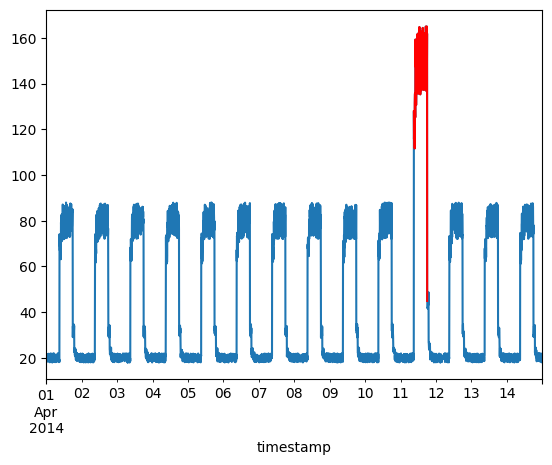

In [78]:
# Data i is an anomaly if samples [(i - timesteps + 1) to (i)] are anomalies.
anomalous_data_indices = []
for data_idx in range(TIME_STEPS - 1, len(df_test_value) - TIME_STEPS + 1):
    if np.all(anomalies[data_idx - TIME_STEPS + 1 : data_idx]):
        anomalous_data_indices.append(data_idx)


# Plotting anomalies in the original test data.
df_subset = df_daily_jumpsup.iloc[anomalous_data_indices]
fig, ax = plt.subplots()
df_daily_jumpsup.plot(legend=False, ax=ax)
df_subset.plot(legend=False, ax=ax, color='r')
plt.show()